# Urbanity

How close a grid cell is to important world cities. Combines Natural Earth
populated places (coords for ~7 300 cities) with the GaWC "World According to
GaWC" tier list (Alpha++ down to Sufficiency) to weight each city by global
importance, then sums an exponential distance decay (λ ≈ 220 km, half-life
≈ 150 km) at each grid cell. Higher = more urban.

In [7]:
import re
import io
import zipfile

import geopandas as gpd
import httpx
import numpy as np
import pandas as pd
import xarray as xr
from bs4 import BeautifulSoup
from scipy.spatial import cKDTree

from common import RAW_DIR, load_grid, save_variable

VARIABLE = 'urbanity'
variable_raw = RAW_DIR / VARIABLE
variable_raw.mkdir(parents=True, exist_ok=True)

## 1. Fetch raw data

Two sources:

* **Natural Earth 10m populated places** (~2.7 MB) — global city point layer
  with `LATITUDE`, `LONGITUDE`, `POP_MAX`.
* **GaWC 2024 classification** — HTML page listing Alpha++ … Sufficiency
  tiers as `<ul>` blocks under `<strong>Tier</strong>` headings, so we parse
  it with BeautifulSoup (the page has no `<table>` so `pandas.read_html`
  doesn't apply). Cached as CSV after the first parse.

In [8]:
NE_URL = 'https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_populated_places.zip'
ne_zip = variable_raw / 'ne_10m_populated_places.zip'

if not ne_zip.exists():
    print(f'downloading {NE_URL}')
    from common import download
    await download(NE_URL, ne_zip)

GAWC_URL = 'https://gawc.lboro.ac.uk/gawc-worlds/the-world-according-to-gawc/world-cities-2024/'
gawc_csv = variable_raw / 'gawc_2024.csv'

if not gawc_csv.exists():
    print(f'fetching {GAWC_URL}')
    html = httpx.get(GAWC_URL, timeout=30, follow_redirects=True).text
    soup = BeautifulSoup(html, 'html.parser')
    tiers = ['Alpha++', 'Alpha+', 'Alpha', 'Alpha-',
             'Beta+',  'Beta',   'Beta-',
             'Gamma+', 'Gamma',  'Gamma-',
             'High Sufficiency', 'Sufficiency']
    rows = []
    for strong in soup.find_all('strong'):
        label = strong.get_text(strip=True)
        if label not in tiers:
            continue
        nxt = strong.find_parent().find_next_sibling()
        while nxt and nxt.name not in ('ul', 'p'):
            nxt = nxt.find_next_sibling()
        if nxt and nxt.name == 'ul':
            for li in nxt.find_all('li'):
                city = li.get_text(strip=True)
                if city:
                    rows.append((label, city))
    pd.DataFrame(rows, columns=['tier', 'city']).to_csv(gawc_csv, index=False)

print(f'{ne_zip.name}: {ne_zip.stat().st_size / 1024:.0f} KB')
print(f'{gawc_csv.name}: {sum(1 for _ in open(gawc_csv)) - 1} GaWC cities')

ne_10m_populated_places.zip: 2745 KB
gawc_2024.csv: 335 GaWC cities


## 2. Clean & merge

Load both sources. Build a lookup from cleaned Natural Earth names to their
rows (preferring the higher-population row on name collisions like "Cambridge").
Then match each GaWC city to a Natural Earth entry via a cascading normalizer
that strips parenthetical suffixes (`Atlanta (GA)` → `atlanta`), applies a
small alias table for known name variants (`Bangalore` → `Bengaluru`,
`Copenhagen` → `København`, `Calcutta` → `Kolkata`, …), and falls back to
Natural Earth's `NAMEALT` field.

Every Natural Earth city gets an importance score:

* GaWC-tier cities get `w_tier` (Alpha++ = 12 down to Sufficiency = 1).
* Every other city gets `w_pop = clip(log10(POP_MAX) - 4, 0, 2)` — so a
  100 k-person city ≈ 1.0, a 1 M city ≈ 2.0, and villages contribute ~0.
* Final importance is `max(w_tier, w_pop)` so a Gamma-tier city can't score
  below what its raw population already earns.

In [ ]:
places = gpd.read_file(ne_zip)
gawc = pd.read_csv(gawc_csv)
print(f'{len(places)} places, {len(gawc)} GaWC cities')

TIER_WEIGHTS = {
    'Alpha++': 12, 'Alpha+': 10, 'Alpha': 8, 'Alpha-': 7,
    'Beta+': 6, 'Beta': 5, 'Beta-': 4,
    'Gamma+': 3, 'Gamma': 2.5, 'Gamma-': 2,
    'High Sufficiency': 1.5, 'Sufficiency': 1,
}

# Cleaned name -> Natural Earth row index; keep the highest-pop row per name.
name_to_idx = {}
def register(idx, name):
    if not isinstance(name, str):
        return
    key = name.strip().lower()
    if key and (key not in name_to_idx or
                places.at[idx, 'POP_MAX'] > places.at[name_to_idx[key], 'POP_MAX']):
        name_to_idx[key] = idx

for i in range(len(places)):
    register(i, places.at[i, 'NAMEASCII'])
    register(i, places.at[i, 'NAME'])

# NAMEALT is pipe-separated alternative spellings; fill only unseen keys.
for i in range(len(places)):
    alt = places.at[i, 'NAMEALT']
    if isinstance(alt, str):
        for name in alt.split('|'):
            key = name.strip().lower()
            if key and key not in name_to_idx:
                name_to_idx[key] = i

ALIASES = {
    'bangalore': 'bengaluru',
    'calcutta':  'kolkata',
    'copenhagen':'københavn',
    'antwerp':   'antwerpen',
    'gothenburg':'göteborg',
    'arhus':     'århus',
    'ulan bator':'ulaanbaatar',
    'macao':     'macau',
    'limassol':  'lemesos',
    'port of spain': 'port-of-spain',
    'washington dc': 'washington, d.c.',
    "xi'an": "xi'an",   # curly-apostrophe canonicalization handled below
}

def normalize(name):
    n = name.strip().lower().replace('’', "'")   # curly to straight
    n = ALIASES.get(n, n)
    n = re.sub(r'\s*\(.*?\)\s*', '', n).strip()      # drop parentheticals
    return n

# Assign per-city importance.
tier = pd.Series(index=places.index, dtype=object)
unmatched = []
for _, row in gawc.iterrows():
    key = normalize(row['city'])
    idx = name_to_idx.get(key)
    if idx is None:
        unmatched.append(row['city'])
        continue
    # Higher tier (larger weight) wins if a GaWC city appears twice.
    prev = tier.at[idx]
    if pd.isna(prev) or TIER_WEIGHTS[row['tier']] > TIER_WEIGHTS[prev]:
        tier.at[idx] = row['tier']
print(f'GaWC matched: {len(gawc) - len(unmatched)}/{len(gawc)} '
      f'({100 * (1 - len(unmatched) / len(gawc)):.1f}%); unmatched: {unmatched}')

w_tier = tier.map(TIER_WEIGHTS).fillna(0)
w_pop  = (np.log10(places['POP_MAX'].clip(lower=1)) - 4).clip(0, 2)
places['importance'] = np.maximum(w_tier, w_pop)

active = places[places['importance'] > 0].copy()
print(f'{len(active)} cities with importance > 0')
print(active.nlargest(100, 'importance')[['NAMEASCII', 'ADM0NAME', 'POP_MAX', 'importance']].to_string(index=False))

7342 places, 335 GaWC cities
GaWC matched: 331/335 (98.8%); unmatched: ['Xi’an', 'Labuan', 'St Louis', 'Palo Alto']
6090 cities with importance > 0
                 NAMEASCII                 ADM0NAME  POP_MAX  importance
                  New York United States of America 19040000        12.0
                    London           United Kingdom  8567000        12.0
                     Dubai     United Arab Emirates  1379000        10.0
                   Beijing                    China 11106000        10.0
                  Shanghai                    China 14987000        10.0
                     Tokyo                    Japan 35676000        10.0
                     Paris                   France  9904000        10.0
                    Sydney                Australia  4630000        10.0
                 Singapore                Singapore  5183700        10.0
                 Hong Kong         Hong Kong S.A.R.  7206000        10.0
                    Warsaw                   Pola

## 3. Interpolate onto the grid

Reproject cities and grid cells to Equal Earth (EPSG:8857) — same trick as
`11_sea_proximity.ipynb` — so distances are planar metres. A `cKDTree` over
city coordinates lets us query only the cities within a 1 500 km radius of
each cell (at that distance `exp(-1500/220) ≈ 0.001`, so cutting further-away
cities is lossless). The per-cell urbanity is

    urbanity(cell) = Σ importance_i · exp(-distance_i_m / 220_000)

Chunking the cell loop keeps peak memory small even though there are 129 600
grid cells.

In [33]:
LAMBDA_M = 100_000       # 100 km e-folding distance
CUTOFF_M = 500_000     # ignore cities beyond 500 km (contribution ~1e-3)
CHUNK    = 4_000

grid = load_grid()

city_pts = gpd.GeoSeries(
    gpd.points_from_xy(active['LONGITUDE'].values, active['LATITUDE'].values),
    crs='EPSG:4326',
).to_crs('EPSG:8857')
city_xy = np.column_stack([city_pts.x.values, city_pts.y.values])
importance = active['importance'].values.astype(np.float64)
tree = cKDTree(city_xy)

lat2d, lon2d = np.meshgrid(grid.lat.values, grid.lon.values, indexing='ij')
cell_pts = gpd.GeoSeries(
    gpd.points_from_xy(lon2d.ravel(), lat2d.ravel()),
    crs='EPSG:4326',
).to_crs('EPSG:8857')
cell_xy = np.column_stack([cell_pts.x.values, cell_pts.y.values])

urbanity_flat = np.zeros(cell_xy.shape[0], dtype=np.float64)
for start in range(0, cell_xy.shape[0], CHUNK):
    stop = min(start + CHUNK, cell_xy.shape[0])
    neighbours = tree.query_ball_point(cell_xy[start:stop], r=CUTOFF_M)
    for offset, idxs in enumerate(neighbours):
        if not idxs:
            continue
        idxs = np.asarray(idxs)
        d = np.linalg.norm(cell_xy[start + offset] - city_xy[idxs], axis=1)
        urbanity_flat[start + offset] = (importance[idxs] * np.exp(-d / LAMBDA_M)).sum()

values = xr.DataArray(
    urbanity_flat.reshape(lat2d.shape).astype(np.float32),
    coords={'lat': grid.lat, 'lon': grid.lon},
    dims=('lat', 'lon'),
    name=VARIABLE,
).where(grid.is_land == 1)

print(f'urbanity range: {float(values.min()):.2f} .. {float(values.max()):.2f}')

urbanity range: 0.00 .. 20.25


## 4. Plot

<Axes: title={'center': 'urbanity'}, xlabel='longitude', ylabel='latitude'>

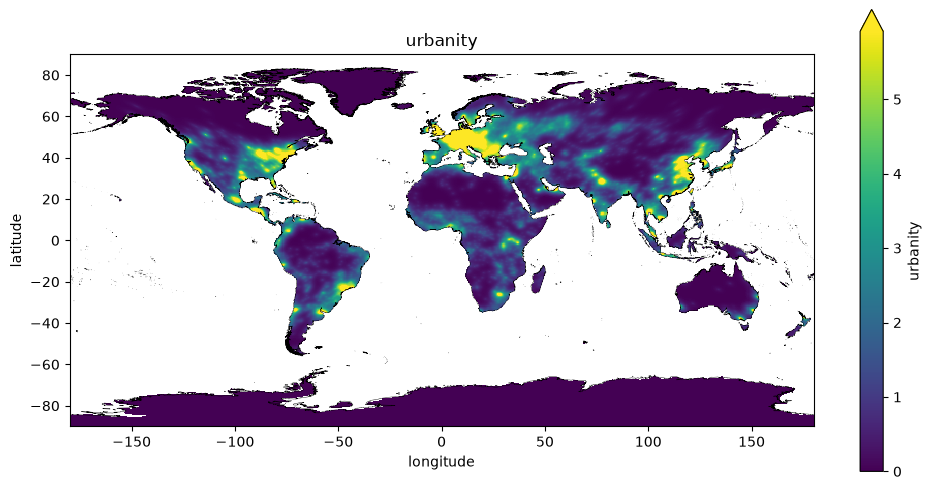

In [34]:
from common import plot_map
plot_map(values, robust=True)

## 5. Save

In [12]:
out = save_variable(values, VARIABLE)
print(f'wrote {out}')

wrote /Users/lutz/Documents/alfatraining/projects/data-science-notebooks/data/world-livable-atlas/processed/urbanity.nc
